<a href="https://colab.research.google.com/github/rudrakshijindal/ai-agriculture-intelligence/blob/main/notebooks/04_baseline_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd, json, os
drive.mount('/content/drive')
out = "/content/drive/MyDrive/ai_agri"
print("Files in Drive folder:", os.listdir(out))
splits = pd.read_csv(f"{out}/splits.csv")
class_to_idx = json.load(open(f"{out}/class_map.json"))
idx_to_class = {i: c for c, i in class_to_idx.items()}
print("Rows:", len(splits), splits["final_split"].value_counts().to_dict(), "| classes:", len(class_to_idx))

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ai_agri'

In [2]:
import zipfile, io, re, json, hashlib, os
import numpy as np, pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from huggingface_hub import hf_hub_download
from sklearn.model_selection import StratifiedGroupKFold

REPO = "mohanty/PlantVillage"
zip_path = hf_hub_download(REPO, "data.zip", repo_type="dataset")

def read_list(name):
    p = hf_hub_download(REPO, f"splits/{name}", repo_type="dataset")
    return [l.strip() for l in open(p) if l.strip()]

train_paths, test_paths = read_list("color_train.txt"), read_list("color_test.txt")
df = pd.DataFrame({"path": train_paths + test_paths,
                   "split": ["train"] * len(train_paths) + ["test"] * len(test_paths)})
df["class_name"] = df["path"].str.split("/").str[2]

# leaf groups
leaf_map = json.load(open(hf_hub_download(REPO, "leaf_grouping/leaf-map.json", repo_type="dataset")))
def key_of(path):
    tail = path.split("/")[-1].split("___")[-1]
    return re.sub(r"\.(jpg|jpeg|png)$", "", tail, flags=re.I).lower()
df["leaf_key"] = df["path"].map(key_of)
def find_group(row):
    entries = leaf_map.get(row["leaf_key"])
    if entries is None: return (None, "none")
    for e in entries:
        if e.rsplit(":::", 1)[0] == row["class_name"]: return (e, "leaf_map")
    if len(entries) == 1: return (entries[0], "leaf_map_class_differs")
    return (None, "none")
res = df.apply(find_group, axis=1, result_type="expand")
df["leaf_group"], df["group_source"] = res[0], res[1]
m = df[df["leaf_group"].notna()]
sp = m.groupby("leaf_group")["split"].nunique()
leaky_groups = set(sp[sp > 1].index)

# exact-duplicate fingerprints (no image decoding needed here)
md5s = []
with zipfile.ZipFile(zip_path) as z:
    for p in tqdm(df["path"], total=len(df)):
        md5s.append(hashlib.md5(z.read(p)).hexdigest())
df["md5"] = md5s

# exclusions
df["exclude_reason"] = ""
mask = (df["split"] == "train") & df["leaf_group"].isin(leaky_groups)
df.loc[mask, "exclude_reason"] = "leaf_in_test"
test_md5 = set(df.loc[df["split"] == "test", "md5"])
mask = (df["split"] == "train") & df["md5"].isin(test_md5) & (df["exclude_reason"] == "")
df.loc[mask, "exclude_reason"] = "exact_duplicate_of_test"
tr = df[(df["split"] == "train") & (df["exclude_reason"] == "")]
df.loc[tr.index[tr.duplicated("md5", keep="first")], "exclude_reason"] = "duplicate_within_train"

# validation split, grouped by leaf
pool = df[(df["split"] == "train") & (df["exclude_reason"] == "")].copy()
pool["group_id"] = np.where(pool["leaf_group"].notna(), pool["leaf_group"], "single::" + pool["path"])
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
tr_idx, va_idx = next(sgkf.split(pool, pool["class_name"], groups=pool["group_id"]))
df["final_split"] = np.where(df["split"] == "test", "test", "excluded")
df.loc[pool.index[tr_idx], "final_split"] = "train"
df.loc[pool.index[va_idx], "final_split"] = "val"

# fix classes with no validation images (move whole leaf groups)
rng = np.random.default_rng(42)
t0 = df.pivot_table(index="class_name", columns="final_split", values="path", aggfunc="count", fill_value=0)
for cls in t0.index[t0["val"] == 0]:
    cand = df[(df["class_name"] == cls) & (df["final_split"] == "train")]
    target = int(round(0.10 * len(cand)))
    groups = cand["leaf_group"].dropna().unique().tolist(); rng.shuffle(groups)
    moved, chosen = 0, []
    for g in groups:
        if moved >= target: break
        chosen.append(g); moved += int((cand["leaf_group"] == g).sum())
    df.loc[df["leaf_group"].isin(chosen) & (df["final_split"] == "train"), "final_split"] = "val"

# safety checks
g = df[df["final_split"].isin(["train", "val"]) & df["leaf_group"].notna()]
both = g.groupby("leaf_group")["final_split"].nunique()
def md5set(s): return set(df.loc[df.final_split == s, "md5"])
table = df.pivot_table(index="class_name", columns="final_split", values="path", aggfunc="count", fill_value=0)
print("Split sizes:", df["final_split"].value_counts().to_dict(), "| total:", len(df))
print("CHECKS (all 0): leaf train/val", int((both > 1).sum()),
      "| dup train/val", len(md5set("train") & md5set("val")),
      "| dup train/test", len(md5set("train") & md5set("test")),
      "| dup val/test", len(md5set("val") & md5set("test")),
      "| classes w/o val", int((table["val"] == 0).sum()),
      "| classes w/o train", int((table["train"] == 0).sum()))

# save to Drive
from google.colab import drive
drive.mount('/content/drive')
out = "/content/drive/MyDrive/ai_agri"
os.makedirs(out, exist_ok=True)
classes = sorted(df["class_name"].unique())
json.dump({c: i for i, c in enumerate(classes)}, open(f"{out}/class_map.json", "w"), indent=1)
df[["path", "class_name", "final_split", "leaf_group", "group_source", "md5", "exclude_reason"]] \
    .to_csv(f"{out}/splits.csv", index=False)
print("Saved to Drive:", os.listdir(out))

data.zip:   0%|          | 0.00/2.18G [00:00<?, ?B/s]

color_train.txt:   0%|          | 0.00/4.15M [00:00<?, ?B/s]

color_test.txt:   0%|          | 0.00/1.02M [00:00<?, ?B/s]

leaf-map.json:   0%|          | 0.00/2.43M [00:00<?, ?B/s]

  0%|          | 0/54305 [00:00<?, ?it/s]

Split sizes: {'train': 39236, 'test': 10709, 'val': 4331, 'excluded': 29} | total: 54305
CHECKS (all 0): leaf train/val 0 | dup train/val 0 | dup train/test 0 | dup val/test 0 | classes w/o val 0 | classes w/o train 0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Drive: ['class_map.json', 'splits.csv']


In [3]:
from google.colab import drive
import pandas as pd, json, os

drive.mount('/content/drive')
out = "/content/drive/MyDrive/ai_agri"
print("Files in Drive folder:", os.listdir(out))

splits = pd.read_csv(f"{out}/splits.csv")
class_to_idx = json.load(open(f"{out}/class_map.json"))
idx_to_class = {i: c for c, i in class_to_idx.items()}

print("Rows:", len(splits))
print(splits["final_split"].value_counts().to_dict())
print("Classes in label map:", len(class_to_idx))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in Drive folder: ['class_map.json', 'splits.csv']
Rows: 54305
{'train': 39236, 'test': 10709, 'val': 4331, 'excluded': 29}
Classes in label map: 38


In [4]:
from huggingface_hub import hf_hub_download
zip_path = hf_hub_download("mohanty/PlantVillage", "data.zip", repo_type="dataset")
print("Ready:", zip_path)

Ready: /root/.cache/huggingface/hub/datasets--mohanty--PlantVillage/snapshots/9e97599868962bd0079b8db4b7f1efa9185fa1e7/data.zip


In [5]:
import zipfile, io, random
import numpy as np, torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SEED, IMG_SIZE, BATCH = 42, 224, 32
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),          # random: training only
    transforms.ToTensor(),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),    # deterministic: validation/test
    transforms.ToTensor(),
])

class ZipLeafDataset(Dataset):
    def __init__(self, frame, zip_path, class_to_idx, transform):
        self.paths = frame["path"].tolist()
        self.labels = [class_to_idx[c] for c in frame["class_name"]]
        self.zip_path, self.transform, self._zip = zip_path, transform, None
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        if self._zip is None:                   # open lazily, once per process
            self._zip = zipfile.ZipFile(self.zip_path)
        img = Image.open(io.BytesIO(self._zip.read(self.paths[i]))).convert("RGB")
        return self.transform(img), self.labels[i]

train_df = splits[splits["final_split"] == "train"]
val_df   = splits[splits["final_split"] == "val"]
train_ds = ZipLeafDataset(train_df, zip_path, class_to_idx, train_tf)
val_ds   = ZipLeafDataset(val_df,   zip_path, class_to_idx, eval_tf)
print("Train images:", len(train_ds), "| Val images:", len(val_ds))

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
xb, yb = next(iter(train_loader))
print("Batch images:", xb.shape, xb.dtype)
print("Batch labels:", yb.shape, "| label range:", int(yb.min()), "to", int(yb.max()))
print("Pixel value range:", float(xb.min()), "to", float(xb.max()))
print("First 5 labels:", [idx_to_class[int(i)] for i in yb[:5]])

# sanity check: deterministic validation transform gives identical output twice
a, _ = val_ds[0]; b, _ = val_ds[0]
print("Validation transform deterministic:", bool(torch.equal(a, b)))

Train images: 39236 | Val images: 4331
Batch images: torch.Size([32, 3, 224, 224]) torch.float32
Batch labels: torch.Size([32]) | label range: 3 to 35
Pixel value range: 0.0 to 1.0
First 5 labels: ['Tomato___Bacterial_spot', 'Blueberry___healthy', 'Apple___healthy', 'Apple___healthy', 'Tomato___Bacterial_spot']
Validation transform deterministic: True


In [6]:
import time, datetime, random
import numpy as np, torch, torchvision
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224 if device.type == "cuda" else 128   # smaller images on CPU to keep training feasible
BATCH = 32
print("Device:", device, "| image size:", IMG_SIZE)

train_tf = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                               transforms.RandomHorizontalFlip(), transforms.ToTensor()])
eval_tf  = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])

def make_loaders(tdf, vdf):
    tl = DataLoader(ZipLeafDataset(tdf, zip_path, class_to_idx, train_tf),
                    batch_size=BATCH, shuffle=True, num_workers=2)
    vl = DataLoader(ZipLeafDataset(vdf, zip_path, class_to_idx, eval_tf),
                    batch_size=BATCH, shuffle=False, num_workers=2)
    return tl, vl

class SmallCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        def block(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o),
                                 nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128), block(128, 256))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

NUM_CLASSES = len(class_to_idx)
m = SmallCNN(NUM_CLASSES).to(device)
print("Parameters:", sum(p.numel() for p in m.parameters()))
xb, yb = next(iter(make_loaders(train_df.head(64), val_df.head(64))[0]))
with torch.no_grad():
    print("Output shape:", tuple(m(xb.to(device)).shape), "(expected (32,", NUM_CLASSES, "))")

Device: cpu | image size: 128
Parameters: 399142
Output shape: (32, 38) (expected (32, 38 ))


In [9]:
from google.colab import drive
import pandas as pd, json, os, zipfile, io, random, time, datetime
import numpy as np, torch, torchvision
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

drive.mount('/content/drive')
out = "/content/drive/MyDrive/ai_agri"
splits = pd.read_csv(f"{out}/splits.csv")
class_to_idx = json.load(open(f"{out}/class_map.json"))
idx_to_class = {i: c for c, i in class_to_idx.items()}
zip_path = hf_hub_download("mohanty/PlantVillage", "data.zip", repo_type="dataset")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224 if device.type == "cuda" else 128
BATCH = 32
print("Device:", device, "| image size:", IMG_SIZE)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

train_tf = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                               transforms.RandomHorizontalFlip(), transforms.ToTensor()])
eval_tf  = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])

class ZipLeafDataset(Dataset):
    def __init__(self, frame, zip_path, class_to_idx, transform):
        self.paths = frame["path"].tolist()
        self.labels = [class_to_idx[c] for c in frame["class_name"]]
        self.zip_path, self.transform, self._zip = zip_path, transform, None
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        if self._zip is None:
            self._zip = zipfile.ZipFile(self.zip_path)
        img = Image.open(io.BytesIO(self._zip.read(self.paths[i]))).convert("RGB")
        return self.transform(img), self.labels[i]

train_df = splits[splits["final_split"] == "train"]
val_df   = splits[splits["final_split"] == "val"]

def make_loaders(tdf, vdf):
    tl = DataLoader(ZipLeafDataset(tdf, zip_path, class_to_idx, train_tf),
                    batch_size=BATCH, shuffle=True, num_workers=2)
    vl = DataLoader(ZipLeafDataset(vdf, zip_path, class_to_idx, eval_tf),
                    batch_size=BATCH, shuffle=False, num_workers=2)
    return tl, vl

class SmallCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        def block(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o),
                                 nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128), block(128, 256))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

NUM_CLASSES = len(class_to_idx)

def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    tot, correct, n, P, L = 0.0, 0, 0, [], []
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out_ = model(x); loss = criterion(out_, y)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            tot += loss.item() * len(y); n += len(y)
            p = out_.argmax(1); correct += (p == y).sum().item()
            P.append(p.cpu()); L.append(y.cpu())
    P, L = torch.cat(P).numpy(), torch.cat(L).numpy()
    return tot / n, correct / n, f1_score(L, P, average="macro", zero_division=0)

def fit(model, tl, vl, epochs, patience, lr=1e-3, ckpt_path=None, hist_path=None):
    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}
    best_f1, best_epoch, bad = -1.0, -1, 0
    for ep in range(1, epochs + 1):
        t0 = time.time()
        trl, tra, _ = run_epoch(model, tl, criterion, opt)
        vl_, va, vf = run_epoch(model, vl, criterion)
        for k, v in zip(hist, [trl, tra, vl_, va, vf]): hist[k].append(v)
        print(f"epoch {ep}/{epochs} | train loss {trl:.4f} acc {tra:.4f} | "
              f"val loss {vl_:.4f} acc {va:.4f} macroF1 {vf:.4f} | {time.time()-t0:.0f}s")
        if vf > best_f1:                      # selection rule fixed in advance: best val macro F1
            best_f1, best_epoch, bad = vf, ep, 0
            if ckpt_path:
                torch.save({"model_state": model.state_dict(), "class_to_idx": class_to_idx,
                            "config": {"arch": "SmallCNN", "img_size": IMG_SIZE, "batch": BATCH,
                                       "lr": lr, "optimizer": "AdamW", "weight_decay": 1e-4,
                                       "seed": SEED, "epoch": ep, "val_macro_f1": best_f1,
                                       "torch": torch.__version__, "torchvision": torchvision.__version__,
                                       "device": str(device), "date": str(datetime.date.today())}},
                           ckpt_path)
        else:
            bad += 1
        if hist_path:
            json.dump({"history": hist, "best_epoch": best_epoch, "best_val_macro_f1": best_f1},
                      open(hist_path, "w"))
        if bad >= patience:
            print(f"Early stopping: no improvement for {patience} epochs."); break
    return hist, best_epoch, best_f1

print("Train:", len(train_df), "| Val:", len(val_df), "| classes:", NUM_CLASSES)
print("Everything restored.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu | image size: 128
Train: 39236 | Val: 4331 | classes: 38
Everything restored.


In [7]:
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    tot, correct, n, P, L = 0.0, 0, 0, [], []
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out_ = model(x); loss = criterion(out_, y)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            tot += loss.item() * len(y); n += len(y)
            p = out_.argmax(1); correct += (p == y).sum().item()
            P.append(p.cpu()); L.append(y.cpu())
    P, L = torch.cat(P).numpy(), torch.cat(L).numpy()
    return tot / n, correct / n, f1_score(L, P, average="macro", zero_division=0)

def fit(model, tl, vl, epochs, patience, lr=1e-3, ckpt_path=None, hist_path=None):
    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}
    best_f1, best_epoch, bad = -1.0, -1, 0
    for ep in range(1, epochs + 1):
        t0 = time.time()
        trl, tra, _ = run_epoch(model, tl, criterion, opt)
        vl_, va, vf = run_epoch(model, vl, criterion)
        for k, v in zip(hist, [trl, tra, vl_, va, vf]): hist[k].append(v)
        print(f"epoch {ep}/{epochs} | train loss {trl:.4f} acc {tra:.4f} | "
              f"val loss {vl_:.4f} acc {va:.4f} macroF1 {vf:.4f} | {time.time()-t0:.0f}s")
        if vf > best_f1:                      # selection rule fixed in advance: best val macro F1
            best_f1, best_epoch, bad = vf, ep, 0
            if ckpt_path:
                torch.save({"model_state": model.state_dict(), "class_to_idx": class_to_idx,
                            "config": {"arch": "SmallCNN", "img_size": IMG_SIZE, "batch": BATCH,
                                       "lr": lr, "optimizer": "AdamW", "weight_decay": 1e-4,
                                       "seed": SEED, "epoch": ep, "val_macro_f1": best_f1,
                                       "torch": torch.__version__, "torchvision": torchvision.__version__,
                                       "device": str(device), "date": str(datetime.date.today())}},
                           ckpt_path)
        else:
            bad += 1
        if hist_path:
            json.dump({"history": hist, "best_epoch": best_epoch, "best_val_macro_f1": best_f1},
                      open(hist_path, "w"))
        if bad >= patience:
            print(f"Early stopping: no improvement for {patience} epochs."); break
    return hist, best_epoch, best_f1
print("Training functions ready.")

Training functions ready.


In [8]:
tl_s, vl_s = make_loaders(train_df.sample(512, random_state=SEED), val_df.sample(256, random_state=SEED))
smoke = SmallCNN(NUM_CLASSES).to(device)
t0 = time.time()
fit(smoke, tl_s, vl_s, epochs=3, patience=3)
per_epoch = (time.time() - t0) / 3
est = per_epoch / 512 * len(train_df) / 60
print(f"\nRough estimate for ONE full epoch: {est:.1f} minutes (includes start-up cost, so likely an overestimate).")

epoch 1/3 | train loss 3.0199 acc 0.2227 | val loss 3.8125 acc 0.0664 macroF1 0.0034 | 46s
epoch 2/3 | train loss 2.4212 acc 0.3594 | val loss 4.6375 acc 0.1094 macroF1 0.0210 | 42s
epoch 3/3 | train loss 2.2020 acc 0.4336 | val loss 3.0767 acc 0.2773 macroF1 0.0605 | 42s

Rough estimate for ONE full epoch: 55.4 minutes (includes start-up cost, so likely an overestimate).


In [10]:
import time
ds = ZipLeafDataset(train_df.head(256), zip_path, class_to_idx, eval_tf)
t0 = time.time()
items = [ds[i] for i in range(len(ds))]
t_load = time.time() - t0
print(f"Load + decode + resize, 256 images, 1 process: {t_load:.1f}s -> {256/t_load:.0f} images/s")

x = torch.stack([a for a, _ in items[:32]]).to(device)
y = torch.tensor([b for _, b in items[:32]]).to(device)
mdl = SmallCNN(NUM_CLASSES).to(device)
opt = torch.optim.AdamW(mdl.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
t0 = time.time()
for _ in range(8):
    opt.zero_grad(); loss = crit(mdl(x), y); loss.backward(); opt.step()
t_comp = time.time() - t0
print(f"Model forward+backward, 8 batches of 32 (256 images): {t_comp:.1f}s -> {256/t_comp:.0f} images/s")
print("Device:", device)

Load + decode + resize, 256 images, 1 process: 2.8s -> 93 images/s
Model forward+backward, 8 batches of 32 (256 images): 14.7s -> 17 images/s
Device: cpu


In [11]:
IMG_SIZE = 64
train_tf = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                               transforms.RandomHorizontalFlip(), transforms.ToTensor()])
eval_tf  = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])

ds = ZipLeafDataset(train_df.head(256), zip_path, class_to_idx, eval_tf)
items = [ds[i] for i in range(len(ds))]
x = torch.stack([a for a, _ in items[:32]]).to(device)
y = torch.tensor([b for _, b in items[:32]]).to(device)
mdl = SmallCNN(NUM_CLASSES).to(device)
opt = torch.optim.AdamW(mdl.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
opt.zero_grad(); crit(mdl(x), y).backward(); opt.step()     # warm-up step, not timed
t0 = time.time()
for _ in range(8):
    opt.zero_grad(); loss = crit(mdl(x), y); loss.backward(); opt.step()
t = time.time() - t0
sp = 256 / t
print(f"IMG_SIZE {IMG_SIZE}: model speed {sp:.0f} images/s -> about {len(train_df)/sp/60:.0f} min per training epoch (compute only)")

IMG_SIZE 64: model speed 80 images/s -> about 8 min per training epoch (compute only)


In [12]:
IMG_SIZE = 64
train_tf = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                               transforms.RandomHorizontalFlip(), transforms.ToTensor()])
eval_tf  = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])

EPOCHS, PATIENCE = 3, 3
tl, vl = make_loaders(train_df, val_df)
model = SmallCNN(NUM_CLASSES).to(device)
ckpt = f"{out}/baseline_cnn_best.pt"

print(f"Training SmallCNN | device {device} | image size {IMG_SIZE} | epochs {EPOCHS} | "
      f"train {len(train_df)} | val {len(val_df)}")
hist, best_epoch, best_f1 = fit(model, tl, vl, EPOCHS, PATIENCE, ckpt_path=ckpt,
                                hist_path=f"{out}/baseline_cnn_history.json")
print("\nBest epoch:", best_epoch, "| best validation macro F1:", round(best_f1, 4))
print("Test set used in Week 5: NO")

Training SmallCNN | device cpu | image size 64 | epochs 3 | train 39236 | val 4331
epoch 1/3 | train loss 0.9158 acc 0.7374 | val loss 0.9569 acc 0.6934 macroF1 0.6081 | 522s
epoch 2/3 | train loss 0.3656 acc 0.8866 | val loss 0.9071 acc 0.7409 macroF1 0.6500 | 514s
epoch 3/3 | train loss 0.2575 acc 0.9176 | val loss 0.5554 acc 0.8151 macroF1 0.7272 | 521s

Best epoch: 3 | best validation macro F1: 0.7272
Test set used in Week 5: NO


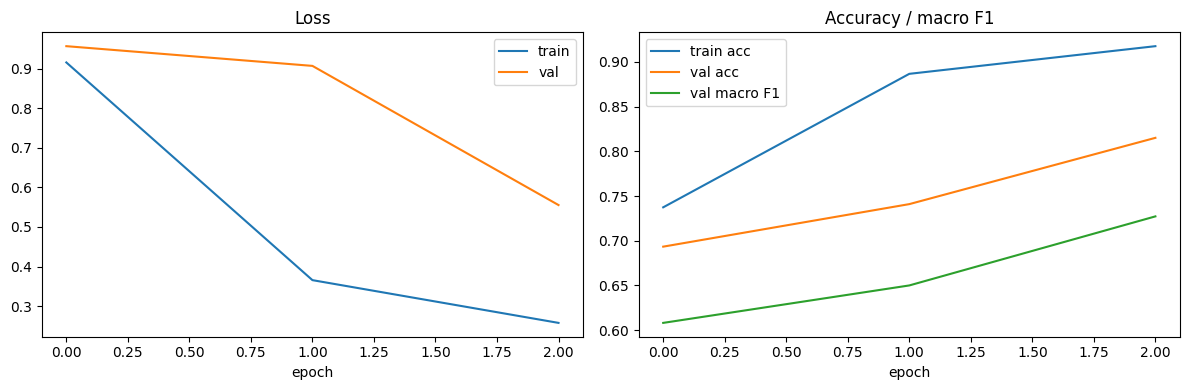

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL torch.torch_version.TorchVersion was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torch.torch_version.TorchVersion])` or the `torch.serialization.safe_globals([torch.torch_version.TorchVersion])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load 

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["train_loss"], label="train"); ax[0].plot(hist["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist["train_acc"], label="train acc"); ax[1].plot(hist["val_acc"], label="val acc")
ax[1].plot(hist["val_macro_f1"], label="val macro F1")
ax[1].set_title("Accuracy / macro F1"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{out}/baseline_cnn_curves.png", dpi=120); plt.show()

ck = torch.load(ckpt, map_location=device)
reloaded = SmallCNN(NUM_CLASSES).to(device); reloaded.load_state_dict(ck["model_state"])
rl, ra, rf = run_epoch(reloaded, vl, nn.CrossEntropyLoss())
print("Saved config:", ck["config"])
print(f"Reloaded checkpoint -> val loss {rl:.4f} | acc {ra:.4f} | macro F1 {rf:.4f}")
print(f"Best-epoch macro F1 recorded during training: {best_f1:.4f}")

In [14]:
ck = torch.load(ckpt, map_location=device, weights_only=False)   # our own file, trusted
reloaded = SmallCNN(NUM_CLASSES).to(device)
reloaded.load_state_dict(ck["model_state"])
rl, ra, rf = run_epoch(reloaded, vl, nn.CrossEntropyLoss())

print("Saved config:", ck["config"])
print(f"Reloaded checkpoint -> val loss {rl:.4f} | acc {ra:.4f} | macro F1 {rf:.4f}")
print(f"Best-epoch macro F1 recorded during training: {best_f1:.4f}")
print("Best epoch:", best_epoch)

Saved config: {'arch': 'SmallCNN', 'img_size': 64, 'batch': 32, 'lr': 0.001, 'optimizer': 'AdamW', 'weight_decay': 0.0001, 'seed': 42, 'epoch': 3, 'val_macro_f1': 0.7272259821098267, 'torch': '2.11.0+cpu', 'torchvision': '0.26.0+cpu', 'device': 'cpu', 'date': '2026-10-10'}
Reloaded checkpoint -> val loss 0.5554 | acc 0.8151 | macro F1 0.7272
Best-epoch macro F1 recorded during training: 0.7272
Best epoch: 3
